In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem, zscore
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d
import pickle
from skimage import io
import glob
from scipy.ndimage import uniform_filter
import shutil

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
lat='/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
for name in os.listdir(lat):
    if 'event' in name and 'best' in name:
        with open(os.path.join(lat,name), 'rb') as file:
            event_times_struct = pickle.load(file)
            f=list(event_times_struct.keys())[0]
            behaviors=list(event_times_struct[f].keys())

In [3]:
behaviors

['inc', 'dec', 'flat']

In [4]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
fly_list=['208', '209', '210', '217', '218', '226', '227', '228', '233', '234', '239', '240', '241', '242', '249', '250']
behave=['total', 'inc', 'dec', 'flat']
step_size=20
files = os.listdir(later_dir)

STAs={}
for file in files:
    if file in behave:
        STAs[file]=[]
        load_dir=os.path.join(later_dir,file)
        sub_files=os.listdir(load_dir)
        for sub_file in sub_files:
            if 'STA' in sub_file and str(step_size) in sub_file:
                print(sub_file)
                STA_path=os.path.join(load_dir,sub_file)
                with h5py.File(STA_path, 'r') as hf:
                    sta = hf['data'][:]
                    dimss = np.shape(sta)
                    print(f"{file} shape is {dimss}")
                    STAs[file]=sta
# STA=np.load(os.path.join(later_dir,'giant_STA.npy'))

STA_total_20.h5
total shape is (120, 314, 146, 91)
STA_total_20.h5
flat shape is (120, 314, 146, 91)
STA_total_20.h5
inc shape is (120, 314, 146, 91)
STA_total_20.h5
dec shape is (120, 314, 146, 91)


In [5]:
# %%time
# total_giant_STA={}
# count = len(fly_list)
# for fly in fly_list:
#     file_name = f"{fly}_stepsize_{step_size}_STA.h5"
#     STA_path = os.path.join(later_dir,file_name)
#     if os.path.exists(STA_path):
#         with h5py.File(STA_path, 'r') as hf:
#                 brain = hf['data'][:]
#                 dimsb = np.shape(brain)
#                 print(f"Brain shape is {dimsb}")
#                 total_giant_STA[fly]=brain
# total_giant_STA['total']=STA

In [6]:
# len(total_giant_STA.keys())

In [7]:
fixed = brainsss.load_fda_meanbrain()
masked=np.where(fixed.numpy()[None,...]>0.1, STAs['total'], np.nan)

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning:

All-NaN slice encountered



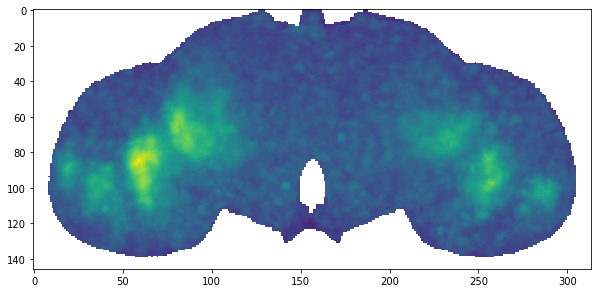

In [8]:
plt.figure(figsize=(10,10))
plt.imshow(np.nanmax(masked[75][:,:,:], axis=-1).T)

In [9]:
fixed = brainsss.load_fda_meanbrain()
flattened={}
for key in STAs:
    print(key)
    masked=np.where(fixed.numpy()[None,...]>0.1, STAs[key], np.nan)
    nt, nx, ny, nz = np.shape(masked)
    reshape=nx*ny*nz
    flat_total=np.reshape(masked, (nt, reshape))
    flat_mean = np.nanmean(flat_total, axis=-1)
    flattened[key]=np.asarray(flat_mean)

total
flat
inc
dec


In [10]:
STAs['total'].shape

(120, 314, 146, 91)

In [12]:
cluster_dir = os.path.join(later_dir, 'clustering')
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [ ]:
%%time
load_dir=os.path.join(later_dir,'total')
cc='_2'
n_clusters=2000
supervox_avgs={}
for fly in fly_list:
    supervox_avgs[fly]=[]
    for file in os.listdir(load_dir):
        if fly in file and cc in file:
            temp_path=os.path.join(load_dir,file)
            with h5py.File(temp_path, 'r') as hf:
                brain = hf['brain']
                dimss = np.shape(brain)
                print(f"{file} shape is {dimss}")
                for z in range(dimss[-2]):
                    neural_activity = brain[:,:,z,:].reshape(-1, dimss[3])
            #         print(np.shape(neural_activity))
                    signals = []
                    for cluster_num in range(n_clusters):
                        cluster_indicies = np.where(giant_cluster_labels[z,:]==cluster_num)[0]
                        mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
                        signals.append(mean_signal)
                    signals = np.asarray(signals)
                    supervox_avgs[fly].append(signals)
    print(f"Supervox shape is {np.shape(supervox_avgs[fly])}") 

208_tf_total_2.h5 shape is (314, 146, 91, 1030)
Supervox shape is (91, 2000, 1030)
209_tf_total_2.h5 shape is (314, 146, 91, 1039)
Supervox shape is (91, 2000, 1039)
210_tf_total_2.h5 shape is (314, 146, 91, 1025)
Supervox shape is (91, 2000, 1025)
217_tf_total_2.h5 shape is (314, 146, 91, 1025)
Supervox shape is (91, 2000, 1025)
218_tf_total_2.h5 shape is (314, 146, 91, 1039)
Supervox shape is (91, 2000, 1039)
226_tf_total_2.h5 shape is (314, 146, 91, 1030)
Supervox shape is (91, 2000, 1030)
227_tf_total_2.h5 shape is (314, 146, 91, 1030)
Supervox shape is (91, 2000, 1030)
228_tf_total_2.h5 shape is (314, 146, 91, 1030)
Supervox shape is (91, 2000, 1030)
233_tf_total_2.h5 shape is (314, 146, 91, 1035)
Supervox shape is (91, 2000, 1035)
234_tf_total_2.h5 shape is (314, 146, 91, 1030)
Supervox shape is (91, 2000, 1030)
239_tf_total_2.h5 shape is (314, 146, 91, 1035)
Supervox shape is (91, 2000, 1035)
240_tf_total_2.h5 shape is (314, 146, 91, 1039)
Supervox shape is (91, 2000, 1039)
241_

In [49]:
later_path = os.path.join(later_dir, 'individual_supervox_dict.h5')

with open(later_path, 'wb') as file:
    pickle.dump(supervox_avgs, file)

In [41]:
avgs=[]
for key in supervox_avgs:
    temp = np.asarray(supervox_avgs[key])[...,:1024]
    mean = np.nanmean(temp, axis=(0,1))
    avgs.append(mean)

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:4: RuntimeWarning:

Mean of empty slice



In [42]:
avgs=np.asarray(avgs)
print(avgs.shape)
total_avg=np.nanmean(avgs,axis=0)
print(total_avg.shape)

(16, 1024)
(1024,)


/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning:

Mean of empty slice



In [43]:
total_avg

array([-2.7547139e-04, -2.7306138e-05, -1.0180365e-03, ...,
                  nan,            nan,            nan], dtype=float32)

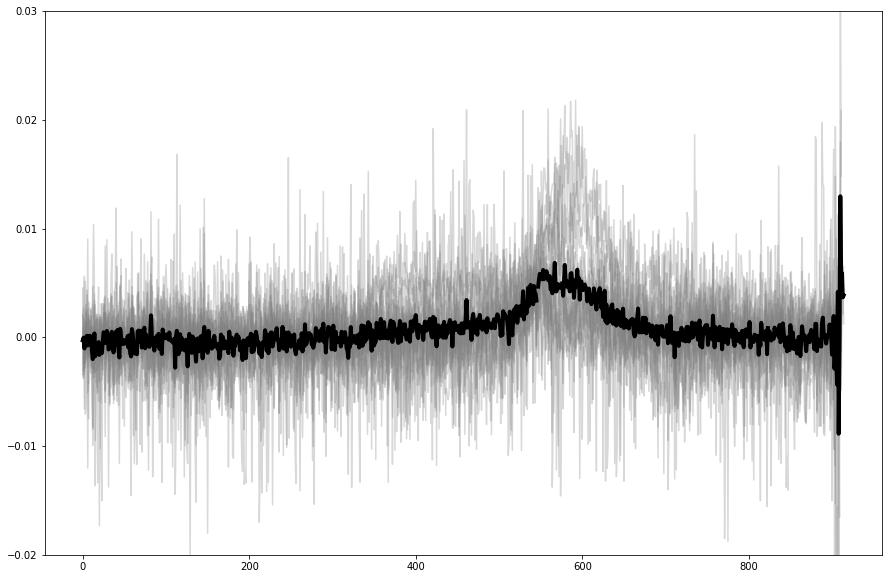

In [47]:
fig, axs=plt.subplots(figsize=(15,10))

axs.plot(avgs.T, color='gray', alpha=0.3);
axs.plot(total_avg, color='k', lw=4)
axs.set_ylim(-0.02,0.03);
# axs.axvline(160,color='k',linestyle='--',lw=2)
# axs.axvline(60,color='k',linestyle='--',lw=2)

In [25]:
vio_data=np.where(fixed.numpy()[None,...]>0.1, total_giant_STA['total'], np.nan)

In [28]:
nt, nx, ny, nz = np.shape(vio_data)
reshape=nx*ny*nz
flat_total=np.reshape(vio_data, (nt, reshape))
np.shape(flat_total)

(240, 4171804)

In [62]:
clean_viodata = np.asarray([time[~np.isnan(time)] for time in flat_total])

In [63]:
clean_viodata=clean_viodata*1e3

In [68]:
np.shape(flattened['total'])

(240,)

In [122]:
steps=10
range_end = np.shape(flattened['total'])[0]
new_data=[]
for i in range(0,range_end, steps):
    temp=[]
    for fly in flattened:
        if fly!='total':
            end = i + steps if i + steps < range_end else range_end
            print(f"Vol {i} to vol {end}")
            chunk = flattened[fly][i:end,...]
            mean = np.mean(chunk, axis=0)*1e4
            temp.append(mean)
    new_data.append(temp)
print(np.shape(new_data))

Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 0 to vol 10
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 10 to vol 20
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 20 to vol 30
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol 40
Vol 30 to vol

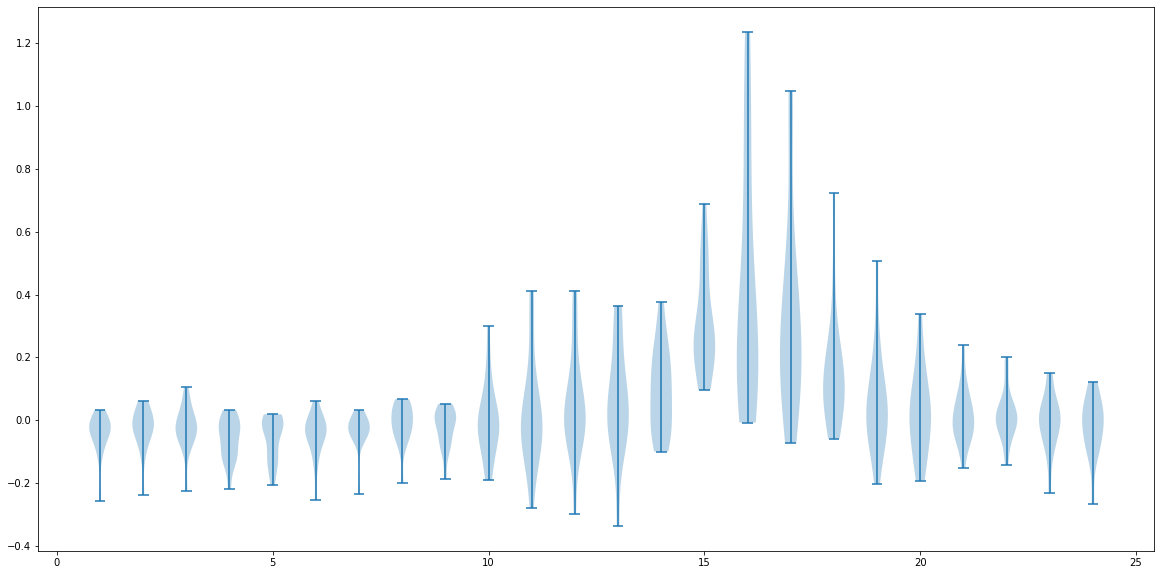

In [79]:
plt.figure(figsize=(20,10))
plt.violinplot(new_data);

In [124]:
np.arange(,15,1)

array([ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

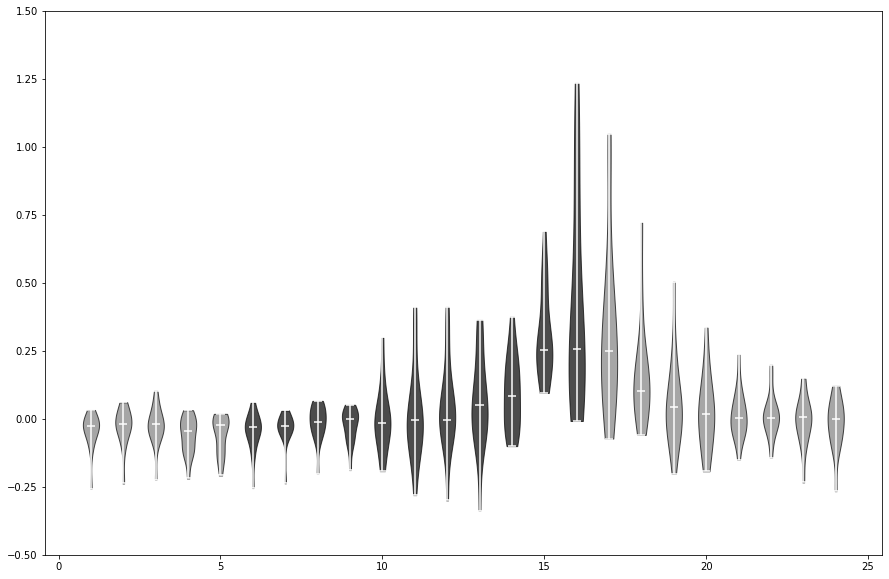

In [127]:
fig, ax = plt.subplots(figsize=(15,10))
ax.set_ylim(-0.5, 1.5);
vp = ax.violinplot(new_data, showmeans=False, showmedians=True)

# Define colors for a subset of violins (e.g., first two violins in red)
subset_indices = np.arange(5,16,1) # Indices of violins to color differently
subset_color = 'black'
default_color = 'grey'

# Change the color of violin bodies
for i, body in enumerate(vp['bodies']):
    if i in subset_indices:
        body.set_facecolor(subset_color)  # Color for subset
    else:
        body.set_facecolor(default_color)  # Default color

    body.set_edgecolor('black')  # Ensure edges are visible
    body.set_alpha(0.7)  # Adjust transparency if needed
for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
    if key in vp:
        vp[key].set_color('w') 
vp['cmins'].set_color('w') 

plt.show()

In [106]:
new_data = np.asarray(new_data)

In [119]:
(np.mean(new_data[16,...])-np.mean(new_data[5,...])/np.abs(np.mean(new_data[5,...])))*100

132.44324133788723

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(np.max(STA[200][:,:,:], axis=-1).T)

In [ ]:
total_path=os.path.join(later_dir,'giant_STA.npy')
np.save(total_path,STA)

In [ ]:
atlas = brainsss.load_roi_atlas()

In [ ]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [ ]:
STA_test=STA[130:140,...]

In [ ]:
np.shape(STA)

In [ ]:
%%time
STA=STA ##### CHANGE THIS
explosions = []
for tp in range(np.shape(STA)[0]):
    input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
    data_to_plot = STA[tp][:,:,::-1]
    vmax = 0.0005 #this was 0.5 for STA <------------
    explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                        roi_masks,
                                                        roi_contours,
                                                        data_to_plot,
                                                        input_canvas,
                                                        vmax=vmax,
                                                        cmap='seismic', diverging=True)#'hot')
    explosions.append(explosion_map)

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(explosions[140][170:,:])

In [ ]:
movie_dir = os.path.join(later_dir, 'movies')
if os.path.exists(movie_dir)==False:
    os.mkdir(movie_dir)
print(movie_dir)

In [ ]:
save_dir = os.path.join(movie_dir,'dff_giant')
if os.path.exists(save_dir)==False:
    os.mkdir(save_dir)
print(save_dir)

In [ ]:
plt.figure(figsize=(10,10))
for i in range(np.shape(STA)[0]):
    print(i)
    plt.imshow(explosions[i][170:,:]) #this was made with cmap=hot
    plt.axis('off')
    fname = os.path.join(save_dir, '{0:05d}.png'.format(i))
    plt.savefig(fname,dpi=300,bbox_inches='tight')